In [1]:
import torch
import torch.nn as nn

# From ch04
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

# Copied from ch03 : MultiheadAttentionV2
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, din, dout, ctxlen, dropout, num_heads, kv_bias=False):
        super().__init__()
        assert(dout % num_heads == 0), "d_out MUST be multiple of num_heads"
        self.dout = dout
        self.num_heads = num_heads
        self.head_dim = dout // num_heads
        self.Wq = torch.nn.Linear(din, dout, bias=kv_bias)
        self.Wk = torch.nn.Linear(din, dout, bias=kv_bias)
        self.Wv = torch.nn.Linear(din, dout, bias=kv_bias)
        self.out_proj = torch.nn.Linear(dout, dout)
        self.dropout = torch.nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(ctxlen, ctxlen), diagonal=1))

    def forward(self, x):
        b, ntok, din = x.shape
        q = self.Wq(x);
        k = self.Wk(x);
        v = self.Wv(x);
        q = q.view(b, ntok, self.num_heads, self.head_dim)
        k = k.view(b, ntok, self.num_heads, self.head_dim)
        v = v.view(b, ntok, self.num_heads, self.head_dim)

        q = q.transpose(1, 2) # make num_heads the dim1 instead of dim2
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        
        att_scores = q @ k.transpose(2, 3); # keep batch (dim0) & num_heads (dim1) in place
        att_scores.masked_fill_(self.mask.bool()[:ntok, :ntok], -torch.inf);
        ws = torch.softmax(att_scores / k.shape[-1]**0.5, dim=-1)
        ws = self.dropout(ws)
        ctx = ws @ v
        ctx = ctx.transpose(1, 2) # make num_heads the dim2
        ctx = ctx.contiguous().view(b, ntok, self.dout)  # join dim2 and dim3 into dim2*dim3

        ctx = self.out_proj(ctx) # join everything to dout*dout
        return ctx

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(cfg["emb_dim"]*4, cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layer(x)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.mha = MultiHeadAttention(din=cfg["emb_dim"], dout=cfg["emb_dim"], ctxlen=cfg["context_length"], num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], kv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_sc = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        sc = x # shortcut
        x = self.norm1(x)
        x = self.mha(x)
        x = self.drop_sc(x)
        x = x + sc

        sc = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_sc(x)
        x = x + sc
        return x

class GPT2(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tk_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self. drop_emb = nn.Dropout(cfg["drop_rate"])

        self.tf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)

    def forward(self, x):
        batch_size, seq_len = x.shape
        tk_emb = self.tk_emb(x)
        pos_emb = self.pos_emb(torch.arange(seq_len, device=x.device))
        # print("pos=", pos_emb)
        x = tk_emb + pos_emb
        x = self.drop_emb(x)
        x = self.tf_blocks(x)
        x = self.final_norm(x)
        logits = self.out(x)
        return logits

In [2]:
GPT_CONFIG_124M = {
 "vocab_size": 50257,
 "context_length": 256, # Changed for small training
 "emb_dim": 768,
 "n_heads": 12,
 "n_layers": 12,
 "drop_rate": 0.1,
 "qkv_bias": False
}

torch.manual_seed(123)
model = GPT2(GPT_CONFIG_124M)
model.eval();

In [3]:
# From ch 04
import tiktoken
def generate_text_simple(model, idx, max_token_gen, ctx_len):
    for _ in range(max_token_gen):
        idx_cond = idx[:, -ctx_len:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probs, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [4]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    return torch.tensor(encoded).unsqueeze(0)

def token_ids_to_text(tokens, tokenizer):
    flatlist = tokens.squeeze(0).tolist()
    return tokenizer.decode(flatlist)

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

In [6]:
tokens = generate_text_simple(model, text_to_token_ids(start_context, tokenizer), 10, GPT_CONFIG_124M["context_length"])
print(tokens, token_ids_to_text(tokens, tokenizer))

tensor([[ 6109,  3626,  6100,   345, 34245,  5139,  2492, 25405, 17434, 17853,
          5308,  3398, 13174, 43071]]) Every effort moves you rentingetic wasnم refres RexMeCHicular stren


# Calculating loss

In [7]:
input = torch.stack((text_to_token_ids("every effort moves", tokenizer)[0], text_to_token_ids("I really like", tokenizer)[0]), dim=0)
output = torch.stack((text_to_token_ids(" effort moves you", tokenizer)[0], text_to_token_ids(" really like chocolate", tokenizer)[0]), dim=0)
input, output

(tensor([[16833,  3626,  6100],
         [   40,  1107,   588]]),
 tensor([[ 3626,  6100,   345],
         [ 1107,   588, 11311]]))

In [8]:
text_to_token_ids("every effort moves", tokenizer)[0]

tensor([16833,  3626,  6100])

In [9]:
with torch.no_grad():
    logits = model(input)
probs = torch.softmax(logits, dim=-1)
probs.shape

torch.Size([2, 3, 50257])

In [10]:
maxprobs = torch.argmax(probs, dim=-1, keepdim=True)
maxprobs

tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])

In [11]:
token_ids_to_text(maxprobs[0].flatten(), tokenizer)

' Armed heNetflix'

In [12]:
target_probs_0 = probs[0, [0, 1, 2], output[0]]
target_probs_1 = probs[1, [0, 1, 2], output[1]]
target_probs_0, target_probs_1

(tensor([7.4540e-05, 3.1061e-05, 1.1563e-05]),
 tensor([1.0337e-05, 5.6776e-05, 4.7559e-06]))

In [13]:
log_probs = torch.log(torch.cat((target_probs_0, target_probs_1)))
log_probs

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])

In [14]:
neg_avg_log_prob = -1 * torch.mean(log_probs) # Called cross-entropy loss
neg_avg_log_prob

tensor(10.7940)

In [15]:
logits.shape, output.shape

(torch.Size([2, 3, 50257]), torch.Size([2, 3]))

In [16]:
logits_flat = logits.flatten(0, 1)
outputs_flat = output.flatten()

logits_flat.shape, outputs_flat.shape

(torch.Size([6, 50257]), torch.Size([6]))

In [17]:
loss = torch.nn.functional.cross_entropy(logits_flat, outputs_flat)
loss

tensor(10.7940)

In [18]:
perplexity = torch.exp(loss)
perplexity

tensor(48725.8672)

# 5.1.3 Training and Validation Loss

In [19]:
with open('the-verdict.txt', 'r', encoding='utf-8') as f:
    book_text = f.read()

In [20]:
encoded = tokenizer.encode(book_text)
len(book_text), len(encoded)

(20479, 5145)

In [21]:
train_ratio = 0.9
split_idx = int(train_ratio * len(book_text))
train_data = book_text[:split_idx]
val_data = book_text[split_idx:]

In [22]:
# Things directly copied from ch 02
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, window_length, stride):
        tokens = tokenizer.encode(txt)
        self.input_tokens = []
        self.output_tokens = []
        for i in range(0, len(tokens) - window_length, stride):
            self.input_tokens.append(torch.tensor(tokens[i:(i+window_length)]))
            self.output_tokens.append(torch.tensor(tokens[(i+1):(i+1+window_length)]))

    def __len__(self):
        return len(self.input_tokens)

    def __getitem__(self, idx):
        return self.input_tokens[idx], self.output_tokens[idx]

def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
 tokenizer = tiktoken.get_encoding("gpt2")
 dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
 dataloader = DataLoader(
     dataset,
     batch_size=batch_size,
     shuffle=shuffle,
     drop_last=drop_last,
     num_workers=num_workers
     )
 return dataloader

In [23]:
torch.manual_seed(123)

In [24]:
train_loader = create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"])
val_loader = create_dataloader_v1(val_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], drop_last=False, shuffle=False)

In [25]:
for x, y in train_loader:
    print(x.shape, y.shape)
print("validation")
for x,y, in val_loader:
    print(x.shape, y.shape)

torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
validation
torch.Size([2, 256]) torch.Size([2, 256])


In [26]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [27]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    if len(data_loader) == 0:
        return float("nan")

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    total_loss = 0
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch (input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches

In [28]:
torch.cuda.is_available()

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


True

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [30]:
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
train_loss, val_loss

(10.987582842508951, 10.98110580444336)

# Train the LLM

In [31]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(f"Epoch: {epoch+1}, step: {global_step:06d}, train_loss: {train_loss:.3f}, val_loss: {val_loss:.3f}")
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen

In [32]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, eval_iter)
    model.train()
    return train_loss, val_loss

In [33]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded_txt = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        generated_tokens = generate_text_simple(model, encoded_txt, 50, context_size)
    decoded_txt = token_ids_to_text(generated_tokens, tokenizer)
    print("Decoded Text: ", decoded_txt.replace("\n", " "))
    model.train()

In [34]:
torch.manual_seed(123)
model = GPT2(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epochs = 10

In [35]:
train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq=5, eval_iter=5, start_context="Every effort moves you", tokenizer=tokenizer)

Epoch: 1, step: 000000, train_loss: 9.818, val_loss: 9.930
Epoch: 1, step: 000005, train_loss: 8.066, val_loss: 8.336
Decoded Text:  Every effort moves you,,,,,,,,,,,,.                                     
Epoch: 2, step: 000010, train_loss: 6.623, val_loss: 7.053
Epoch: 2, step: 000015, train_loss: 6.047, val_loss: 6.605
Decoded Text:  Every effort moves you, and,, and,,,,,,, and,.                                   
Epoch: 3, step: 000020, train_loss: 5.532, val_loss: 6.507
Epoch: 3, step: 000025, train_loss: 5.399, val_loss: 6.389
Decoded Text:  Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had the, and, and, and, and, and, and, and, and, and
Epoch: 4, step: 000030, train_loss: 4.895, val_loss: 6.280
Epoch: 4, step: 000035, train_loss: 4.648, val_loss: 6.304
Decoded Text:  Every effort moves you.  "I the picture.                    "I"I the picture"I had the the honour of the picture and I had been the picture of
Epoch: 5, ste

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [37]:
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epochs_seen, train_losses, label="Training Losses")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation Losses")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, label="Tokens Seen")
    ax2.set_xlabel("Tokens Seen")
    fig.tight_layout()
    plt.show()

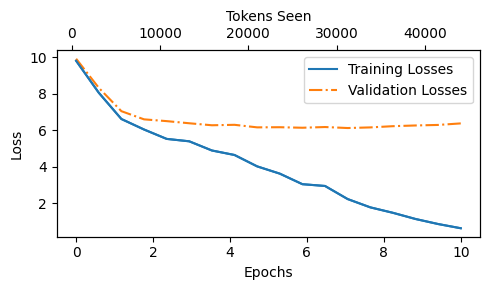

In [38]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

# Text Gen Strategies

In [39]:
model.to("cpu");
model.eval();

In [40]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
 model,
 text_to_token_ids("Every effort moves you", tokenizer),
 25,
 GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




## Temp scaling

In [41]:
vocab = {
 "closer": 0,
 "every": 1,
 "effort": 2,
 "forward": 3,
 "inches": 4,
 "moves": 5,
 "pizza": 6,
 "toward": 7,
 "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [42]:
next_token_logits = torch.tensor(
 [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [43]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [44]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [45]:
def print_sampled_tokens(probas):
 torch.manual_seed(123)
 sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1_000)]
 sampled_ids = torch.bincount(torch.tensor(sample))
 for i, freq in enumerate(sampled_ids):
     print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [46]:
def softmax_with_temperature(logits, temperature):
 scaled_logits = logits / temperature
 return torch.softmax(scaled_logits, dim=0)

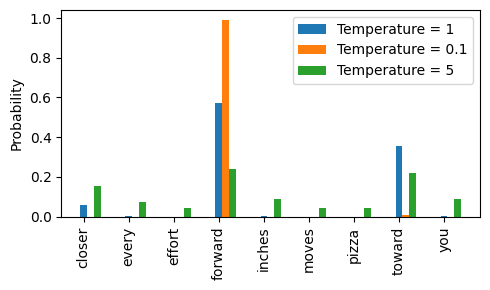

In [47]:
temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
 for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
 rects = ax.bar(x + i * bar_width, scaled_probas[i],
 bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
### Exercise 5.1

for t in temperatures:
    print(f"================= Temp is {t} =================")
    print_sampled_tokens(softmax_with_temperature(next_token_logits, t))

================= Temp is 1 =================
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
================= Temp is 0.1 =================
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
================= Temp is 5 =================
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


In [49]:
for t in temperatures:
    print(f"================= Temp is {t} =================")
    probabilities = softmax_with_temperature(next_token_logits, t)
    pizza_idx = vocab["pizza"]
    pizza_prob = probabilities[pizza_idx].item()
    print(f"In 1000 samples, pizza will appear approximately {pizza_prob * 1000:.2f} times.")

================= Temp is 1 =================
In 1000 samples, pizza will appear approximately 0.10 times.
================= Temp is 0.1 =================
In 1000 samples, pizza will appear approximately 0.00 times.
================= Temp is 5 =================
In 1000 samples, pizza will appear approximately 43.00 times.


## Top k sampling

In [50]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [51]:
for t in temperatures:
    print(f"================= Temp is {t} =================")
    digits = softmax_with_temperature(top_logits, t)
    for idx, digit in enumerate(digits):
        print(f"{digit:.3f} x {inverse_vocab[top_pos[idx].item()]}")

================= Temp is 1 =================
0.578 x forward
0.361 x toward
0.061 x closer
================= Temp is 0.1 =================
0.991 x forward
0.009 x toward
0.000 x closer
================= Temp is 5 =================
0.392 x forward
0.357 x toward
0.251 x closer


In [52]:
new_logits = torch.where(next_token_logits < top_logits[-1], input=torch.tensor(float('-inf')), other=next_token_logits)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [53]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Combining top-k and temp scaling

In [54]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
     for _ in range(max_new_tokens):
         idx_cond = idx[:, -context_size:]
         with torch.no_grad():
             logits = model(idx_cond)
         # print("before: ", logits.shape)
         logits = logits[:, -1, :]
         # print("after: ", logits.shape)
         if top_k is not None:
             top_logits, _ = torch.topk(logits, top_k)
             min_val = top_logits[:, -1]
             # print("min val: ", min_val)
             logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)
         if temperature > 0.0:
             logits = logits / temperature
             probs = torch.softmax(logits, dim=-1)
             idx_next = torch.multinomial(probs, num_samples=1)
         else:
             idx_next = torch.argmax(logits, dim=-1, keepdim=True)
         if idx_next == eos_id:
             break
         idx = torch.cat((idx, idx_next), dim=1)
     return idx

In [55]:
torch.manual_seed(123)
token_ids = generate(
 model=model,
 idx=text_to_token_ids("Every effort moves you", tokenizer),
 max_new_tokens=15,
 context_size=GPT_CONFIG_124M["context_length"],
 top_k=25,
 temperature=1.4
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"
His up surprise. And whenever his glory, when by his head


In [56]:
def call_gen():
    token_ids = generate(
         model=model,
         idx=text_to_token_ids("Every effort moves you", tokenizer),
         max_new_tokens=15,
         context_size=GPT_CONFIG_124M["context_length"],
         top_k=15,
         temperature=1
        )
    print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

In [57]:
call_gen()
call_gen()

Output text:
 Every effort moves you?"

"Yes--quite insensible to the deprecating laugh
Output text:
 Every effort moves you in the room on surprise, he had a smile that lifted the frame called


## Loading & Saving models

In [58]:
torch.save(model.state_dict(), "model.pth")

In [59]:
model = GPT2(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval();

### Save both model and optimizer if you want to continue training the model later

In [60]:
torch.save({
 "model_state_dict": model.state_dict(),
 "optimizer_state_dict": optimizer.state_dict(),
 },
 "model_and_optimizer.pth"
)

In [61]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPT2(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device);
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

In [62]:
train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, 2, eval_freq=5, eval_iter=5, start_context="Every effort moves you", tokenizer=tokenizer)

Epoch: 1, step: 000000, train_loss: 0.456, val_loss: 6.402
Epoch: 1, step: 000005, train_loss: 0.341, val_loss: 6.397
Decoded Text:  Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, when, instinctively embarrassed by my unexpected discovery; and as I turned, my eye fell on a small picture
Epoch: 2, step: 000010, train_loss: 0.283, val_loss: 6.594
Epoch: 2, step: 000015, train_loss: 0.218, val_loss: 6.635
Decoded Text:  Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


# Load weights from OpenAI

In [63]:
!uv pip install tensorflow>=2.15.0 tqdm>=4.66

Audited 2 packages in 3ms


In [64]:
import urllib.request
url = (
 "https://raw.githubusercontent.com/rasbt/"
 "LLMs-from-scratch/main/ch05/"
 "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x778f4de051d0>)

In [65]:
from gpt_download import download_and_load_gpt2

I0000 00:00:1772897077.827832   46298 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772897077.850576   46298 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772897078.441313   46298 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [66]:
settings, params = download_and_load_gpt2(
 model_size="124M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [67]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [68]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [69]:
model_configs = {
 "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
 "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
 "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
 "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [70]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [71]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': True}

In [72]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [73]:
gpt = GPT2(NEW_CONFIG)
gpt.eval();

In [74]:
def assign(left, right):
 if left.shape != right.shape:
     raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
 return torch.nn.Parameter(torch.tensor(right))

In [75]:
import numpy as np
def load_weights_into_gpt(gpt, params):
 gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
 gpt.tk_emb.weight = assign(gpt.tk_emb.weight, params['wte'])

 for b in range(len(params["blocks"])):
     q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
     gpt.tf_blocks[b].mha.Wq.weight = assign(gpt.tf_blocks[b].mha.Wq.weight, q_w.T)
     gpt.tf_blocks[b].mha.Wk.weight = assign(gpt.tf_blocks[b].mha.Wk.weight, k_w.T)
     gpt.tf_blocks[b].mha.Wv.weight = assign(gpt.tf_blocks[b].mha.Wv.weight, v_w.T)
     q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
     gpt.tf_blocks[b].mha.Wq.bias = assign(gpt.tf_blocks[b].mha.Wq.bias, q_b)
     gpt.tf_blocks[b].mha.Wk.bias = assign(gpt.tf_blocks[b].mha.Wk.bias, k_b)
     gpt.tf_blocks[b].mha.Wv.bias = assign(gpt.tf_blocks[b].mha.Wv.bias, v_b)
     gpt.tf_blocks[b].mha.out_proj.weight = assign(gpt.tf_blocks[b].mha.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
     gpt.tf_blocks[b].mha.out_proj.bias = assign(gpt.tf_blocks[b].mha.out_proj.bias, params["blocks"][b]["attn"]["c_proj"]["b"])
     gpt.tf_blocks[b].ff.layer[0].weight = assign(gpt.tf_blocks[b].ff.layer[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
     gpt.tf_blocks[b].ff.layer[0].bias = assign(gpt.tf_blocks[b].ff.layer[0].bias, params["blocks"][b]["mlp"]["c_fc"]["b"])
     gpt.tf_blocks[b].ff.layer[2].weight = assign(gpt.tf_blocks[b].ff.layer[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
     gpt.tf_blocks[b].ff.layer[2].bias = assign(gpt.tf_blocks[b].ff.layer[2].bias, params["blocks"][b]["mlp"]["c_proj"]["b"])
     gpt.tf_blocks[b].norm1.scale = assign(gpt.tf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
     gpt.tf_blocks[b].norm1.shift = assign(gpt.tf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
     gpt.tf_blocks[b].norm2.scale = assign(gpt.tf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
     gpt.tf_blocks[b].norm2.shift = assign(gpt.tf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])
 gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
 gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
 gpt.out.weight = assign(gpt.out.weight, params["wte"])

In [76]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [77]:
torch.manual_seed(123)
token_ids = generate(
 model=gpt,
 idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
 max_new_tokens=25,
 context_size=NEW_CONFIG["context_length"],
 top_k=50,
 temperature=1.5
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


In [78]:
### Exercise 5.5

train_losses, val_losses, tokens_seen = train_model_simple(model, train_loader, val_loader, optimizer, device, 2, eval_freq=5, eval_iter=5, start_context="Every effort moves you", tokenizer=tokenizer)

Epoch: 1, step: 000000, train_loss: 0.229, val_loss: 6.651
Epoch: 1, step: 000005, train_loss: 0.154, val_loss: 6.739
Decoded Text:  Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  "Oh, in the height of his head to look up at the sketch of the donkey. "There were days when I
Epoch: 2, step: 000010, train_loss: 0.128, val_loss: 6.781
Epoch: 2, step: 000015, train_loss: 0.110, val_loss: 6.860
Decoded Text:  Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


In [79]:
## Exercise 5.6

model_name = "gpt2-xl (1558M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024})
NEW_CONFIG.update({"qkv_bias": True})

In [80]:
gpt = GPT2(NEW_CONFIG)
gpt.eval();

In [81]:
settings, params = download_and_load_gpt2(
 model_size="1558M", models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/1558M/checkpoint
File already exists and is up-to-date: gpt2/1558M/encoder.json
File already exists and is up-to-date: gpt2/1558M/hparams.json
File already exists and is up-to-date: gpt2/1558M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/1558M/model.ckpt.index
File already exists and is up-to-date: gpt2/1558M/model.ckpt.meta
File already exists and is up-to-date: gpt2/1558M/vocab.bpe


In [83]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

In [85]:
torch.manual_seed(123)
def call_gen():
    token_ids = generate(
     model=gpt,
     idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
     max_new_tokens=25,
     context_size=NEW_CONFIG["context_length"],
     top_k=50,
     temperature=1.5
    )
    print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

In [86]:
call_gen()
call_gen()
call_gen()

Output text:
 Every effort moves you as far as the next. No amount (and I quote - "Nothing!)

Fulfills you (no matter
Output text:
 Every effort moves you further to where you do not actually want to grow; you are still too much of an outsider. This has been demonstrated clearly
Output text:
 Every effort moves you toward what you cannot get and never gives you nothing," she said. What we all really want, though, Dandridge
